# **Homework 13: Multi-Agent Reinforcement Learning**

#### **Course:** Deep Reinforcement Learning

---
## Problem 1: Nash Equilibrium (Theory)

A Nash Equilibrium (NE) represents a state where no player can improve their outcome by unilaterally changing their strategy. For our games, we'll focus on finding the mixed-strategy NE, where players choose their actions probabilistically.

### 1.1 Standard Rock-Scissors-Paper

Given the standard RSP payoff matrix:

| Player 1 | Rock | Scissors | Paper |
| :--- | :--: | :---: | :---: |
| **Rock** | 0, 0 | 1, -1 | -1, 1 |
| **Scissors**| -1, 1 | 0, 0 | 1, -1 |
| **Paper** | 1, -1 | -1, 1 | 0, 0 |


**Your Task:** Analytically derive the mixed-strategy Nash Equilibrium for this game. Show the steps for setting up the indifference equations for Player 1 and solving for Player 2's equilibrium strategy probabilities $(q_R, q_S, q_P)$. (find the Mixed Nash equilibrium of the game)

Done in report

### 1.2 Modified Rock-Scissors-Paper

Now, consider the modified RSP game where the stakes are higher:

| Player 1 | Rock | Scissors | Paper |
| :--- | :--: | :---: | :---: |
| **Rock** | 0, 0 | 1, -1 | -2, 2 |
| **Scissors**| -1, 1 | 0, 0 | 3, -3 |
| **Paper** | 2, -2 | -3, 3 | 0, 0 |


**Your Task:** Like pervious one Derive the mixed-strategy Nash Equilibrium for this modified game.


Done in report

---
## Problem 2: Learning by Observation - Fictitious Play (Implementation)

Fictitious Play is an intuitive learning algorithm where each agent models its opponent as playing a stationary strategy defined by the historical frequency of their past actions. The agent then plays a **best response** to this belief.

### 2.1 Implementation

**Your Task:** Implement the `simulate_fictitious_play` function below. It should take the payoff matrices for both players and the number of iterations as input. At each step, each player should choose the action that maximizes their expected payoff given the history of the opponent's plays.

**Algorithm:** At each time step $t > 0$, Player $i$ forms a belief that their opponent ($-i$) will play each action $a'$ with a probability equal to its historical frequency. The agent then chooses an action $a_i^*$ that is a best response to this belief.

Let $C_{t-1}(a_{-i})$ be the count of times opponent $-i$ has played action $a_{-i}$ up to step $t-1$. Player $i$'s best response is:
$$a_{i,t}^* = \arg\max_{a_i \in A_i} \sum_{a_{-i} \in A_{-i}} u_i(a_i, a_{-i}) \cdot \frac{C_{t-1}(a_{-i})}{t-1}$$

**Note on Tie-Breaking:** If multiple actions yield the same maximal expected payoff, your agent should choose one of these best responses uniformly at random.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def simulate_fictitious_play(A, B, iterations):
    """
    Simulates Fictitious Play for two players in a normal-form game.

    Args:
        A (np.ndarray): Payoff matrix for Player 1.
        B (np.ndarray): Payoff matrix for Player 2.
        iterations (int): The number of rounds to play.

    Returns:
        tuple: A tuple containing:
            - p1_freq_history (np.ndarray): History of Player 1's action frequencies.
            - p2_freq_history (np.ndarray): History of Player 2's action frequencies.
    """
    ### YOUR CODE HERE ###
    # Initialize action counts and history lists
    # Loop for the specified number of iterations
    # On iteration 0, use a tie-breaking rule (e.g., play action 0)
    # On subsequent iterations, calculate best response to opponent's historical frequencies
    # Update action counts
    # Periodically record the current action frequencies for plotting


    num_actions_p1 = A.shape[0]
    num_actions_p2 = A.shape[1]

    # Initialize action counts and history lists
    p1_counts = np.zeros(num_actions_p1)
    p2_counts = np.zeros(num_actions_p2)
    p1_freq_history = np.zeros((iterations, num_actions_p1))
    p2_freq_history = np.zeros((iterations, num_actions_p2))

    p1_action = np.random.randint(num_actions_p1)
    p2_action = np.random.randint(num_actions_p2)

    # Loop for the specified number of iterations
    for t in range(iterations):
        # Update counts
        p1_counts[p1_action] += 1
        p2_counts[p2_action] += 1

        # Calculate frequencies
        p1_freq = p1_counts / np.sum(p1_counts)
        p2_freq = p2_counts / np.sum(p2_counts)

        # Store history
        p1_freq_history[t] = p1_freq
        p2_freq_history[t] = p2_freq

        # Calculate expected payoffs for the next round
        p1_expected_payoffs = np.dot(A, p2_freq)
        p2_expected_payoffs = np.dot(B.T, p1_freq)

        # Find best responses, handling ties
        best_responses_p1 = np.where(p1_expected_payoffs == np.max(p1_expected_payoffs))[0]
        best_responses_p2 = np.where(p2_expected_payoffs == np.max(p2_expected_payoffs))[0]

        # Choose an action uniformly at random from the best responses
        p1_action = np.random.choice(best_responses_p1)
        p2_action = np.random.choice(best_responses_p2)

    return p1_freq_history, p2_freq_history

# --- Payoff Matrices ---
A_std = np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])
A_mod = np.array([[0, 1, -2], [-1, 0, 3], [2, -3, 0]])
B_std = -A_std
B_mod = -A_mod

### 2.2 Analysis

**Your Task:**
1.  Run your simulation for **1,000,000 iterations** on both the **standard** and **modified** RSP games.
2.  Generate two plots, one for each game. Each plot should show the evolution of Players action frequencies over time and include horizontal lines indicating the theoretical NE probabilities you calculated in Problem 1.
3.  **Analyze your results:** Do the action frequencies converge? If so, do they converge to the Nash Equilibrium? Explain the observed behavior.

In [13]:
iterations = 1000000
p1_freq_history_std, p2_freq_history_std = simulate_fictitious_play(A_std, B_std, iterations)


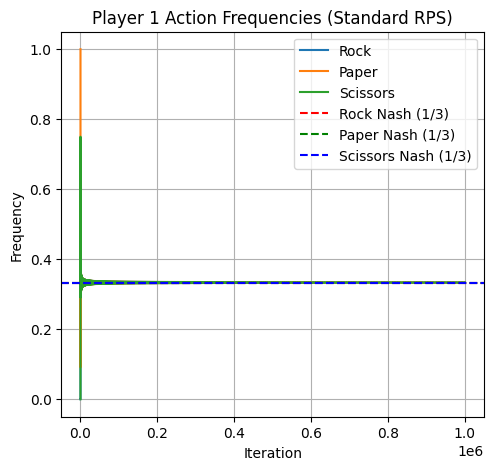

In [14]:

# Plotting for Standard RPS
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p1_freq_history_std[:, 0], label='Rock')
plt.plot(p1_freq_history_std[:, 1], label='Paper')
plt.plot(p1_freq_history_std[:, 2], label='Scissors')

plt.axhline(y=1/3, color='r', linestyle='--', label='Rock Nash (1/3)')
plt.axhline(y=1/3, color='g', linestyle='--', label='Paper Nash (1/3)')
plt.axhline(y=1/3, color='b', linestyle='--', label='Scissors Nash (1/3)')

plt.title('Player 1 Action Frequencies (Standard RPS)')
plt.xlabel('Iteration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

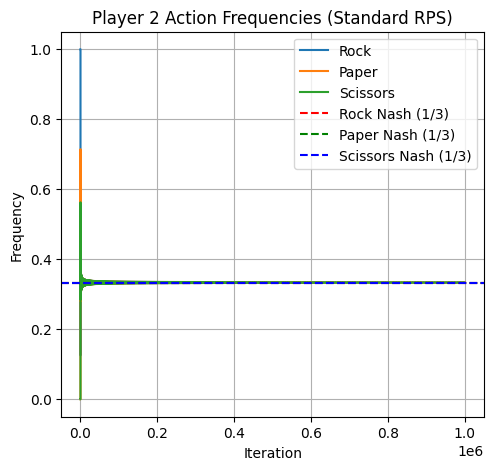

In [15]:

# Plotting for Standard RPS
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p2_freq_history_std[:, 0], label='Rock')
plt.plot(p2_freq_history_std[:, 1], label='Paper')
plt.plot(p2_freq_history_std[:, 2], label='Scissors')

plt.axhline(y=1/3, color='r', linestyle='--', label='Rock Nash (1/3)')
plt.axhline(y=1/3, color='g', linestyle='--', label='Paper Nash (1/3)')
plt.axhline(y=1/3, color='b', linestyle='--', label='Scissors Nash (1/3)')

plt.title('Player 2 Action Frequencies (Standard RPS)')
plt.xlabel('Iteration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

In [16]:
p1_freq_history_mod, p2_freq_history_mod = simulate_fictitious_play(A_mod, B_mod, iterations)

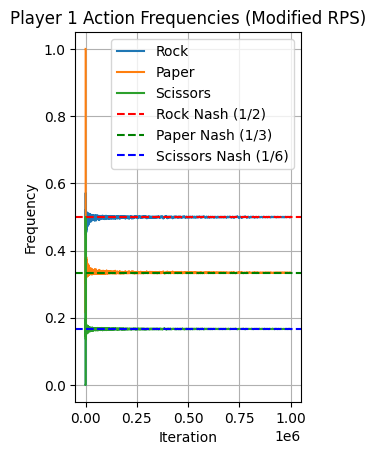

In [17]:
plt.subplot(1, 2, 2)
plt.plot(p1_freq_history_mod[:, 0], label='Rock')
plt.plot(p1_freq_history_mod[:, 1], label='Paper')
plt.plot(p1_freq_history_mod[:, 2], label='Scissors')

plt.axhline(y=1/2, color='r', linestyle='--', label='Rock Nash (1/2)')
plt.axhline(y=1/3, color='g', linestyle='--', label='Paper Nash (1/3)')
plt.axhline(y=1/6, color='b', linestyle='--', label='Scissors Nash (1/6)')


plt.title('Player 1 Action Frequencies (Modified RPS)')
plt.xlabel('Iteration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

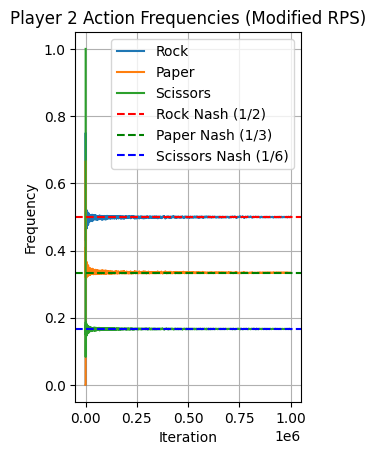

In [18]:
plt.subplot(1, 2, 2)
plt.plot(p2_freq_history_mod[:, 0], label='Rock')
plt.plot(p2_freq_history_mod[:, 1], label='Paper')
plt.plot(p2_freq_history_mod[:, 2], label='Scissors')

plt.axhline(y=1/2, color='r', linestyle='--', label='Rock Nash (1/2)')
plt.axhline(y=1/3, color='g', linestyle='--', label='Paper Nash (1/3)')
plt.axhline(y=1/6, color='b', linestyle='--', label='Scissors Nash (1/6)')


plt.title('Player 2 Action Frequencies (Modified RPS)')
plt.xlabel('Iteration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

**Analyze:**

The two plots show the evolution of the action frequencies for both players over time. The horizontal dashed lines represent the theoretical Nash Equilibrium (NE) probabilities, which are as follows:

Standard RPS: The theoretical NE probabilities for each action are 1/3≈0.33.

Modified RPS: The theoretical NE probabilities for Rock, Paper, and Scissors are 1/2=0.50, 1/3≈0.33, and 1/6≈0.17, respectively.

As the simulations progress, the action frequencies in both plots can be observed to converge toward these theoretical NE probabilities.

**so they did converge to the equilibruim that we found analyticaly**



---
## Problem 3: Fictitious Play with Exploration (Implementation)

Our Fictitious Play agent is purely exploitative. In Reinforcement Learning, we know the importance of the **exploration-exploitation tradeoff**. Let's create an $\epsilon$-greedy version of Fictitious Play.

### 3.1 Implementation

**Your Task:** Create a new function, `simulate_epsilon_greedy_fp`. This function should be similar to your Fictitious Play implementation but include an `epsilon` parameter. At each step, with probability `epsilon`, the agent should choose a random action (explore). With probability `1-epsilon`, it should play the best response (exploit).

In [19]:
def simulate_epsilon_greedy_fp(A, B, iterations, epsilon):
    """
    Simulates epsilon-greedy Fictitious Play.
    """
    num_actions_p1 = A.shape[0]
    num_actions_p2 = A.shape[1]

    p1_counts = np.zeros(num_actions_p1)
    p2_counts = np.zeros(num_actions_p2)
    p1_freq_history = np.zeros((iterations, num_actions_p1))
    p2_freq_history = np.zeros((iterations, num_actions_p2))


    p1_action = np.random.randint(num_actions_p1)
    p2_action = np.random.randint(num_actions_p2)

    # Loop for the specified number of iterations
    for t in range(iterations):
        # Update counts
        p1_counts[p1_action] += 1
        p2_counts[p2_action] += 1

        # Calculate frequencies for the next decision
        p1_freq = p1_counts / np.sum(p1_counts)
        p2_freq = p2_counts / np.sum(p2_counts)

        # Store history
        p1_freq_history[t] = p1_freq
        p2_freq_history[t] = p2_freq

        # Epsilon-greedy logic for Player 1
        if np.random.rand() < epsilon:
            # Explore: choose a random action
            p1_action = np.random.randint(num_actions_p1)
        else:
            # Exploit: choose best response
            p1_expected_payoffs = np.dot(A, p2_freq)
            best_responses_p1 = np.where(p1_expected_payoffs == np.max(p1_expected_payoffs))[0]
            p1_action = np.random.choice(best_responses_p1)

        # Epsilon-greedy logic for Player 2
        if np.random.rand() < epsilon:
            # Explore: choose a random action
            p2_action = np.random.randint(num_actions_p2)
        else:
            # Exploit: choose best response
            p2_expected_payoffs = np.dot(B.T, p1_freq)
            best_responses_p2 = np.where(p2_expected_payoffs == np.max(p2_expected_payoffs))[0]
            p2_action = np.random.choice(best_responses_p2)

    return p1_freq_history, p2_freq_history

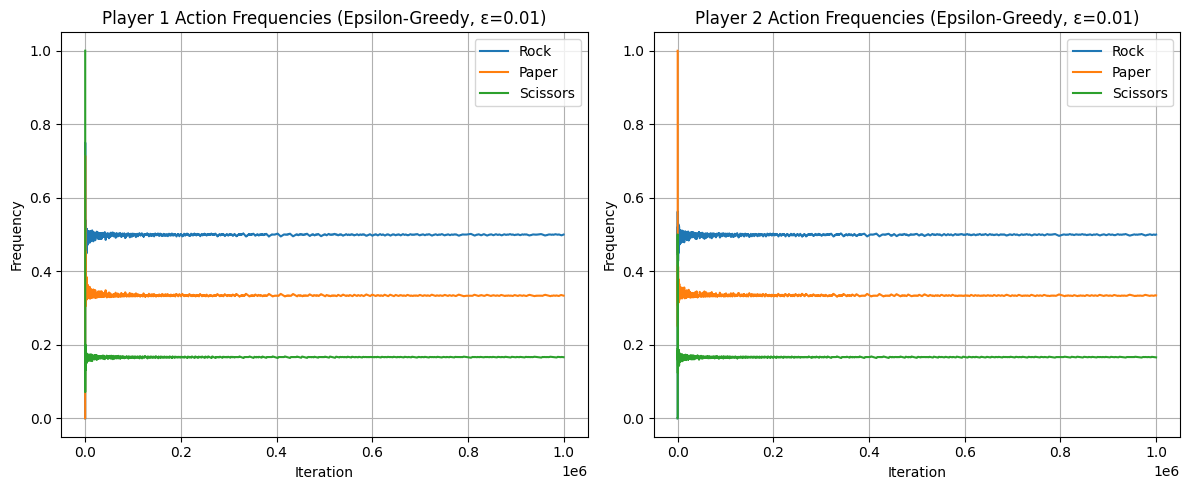

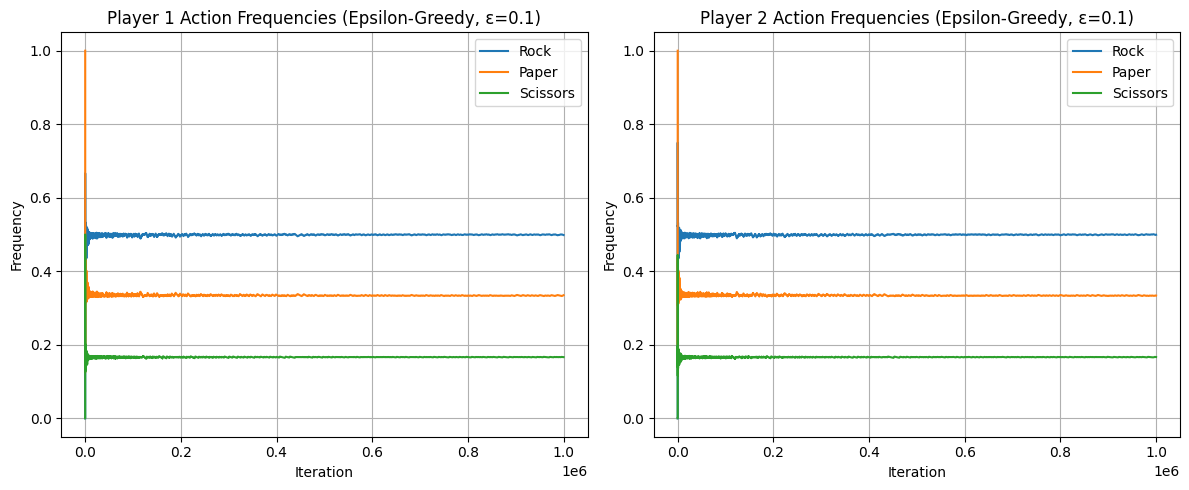

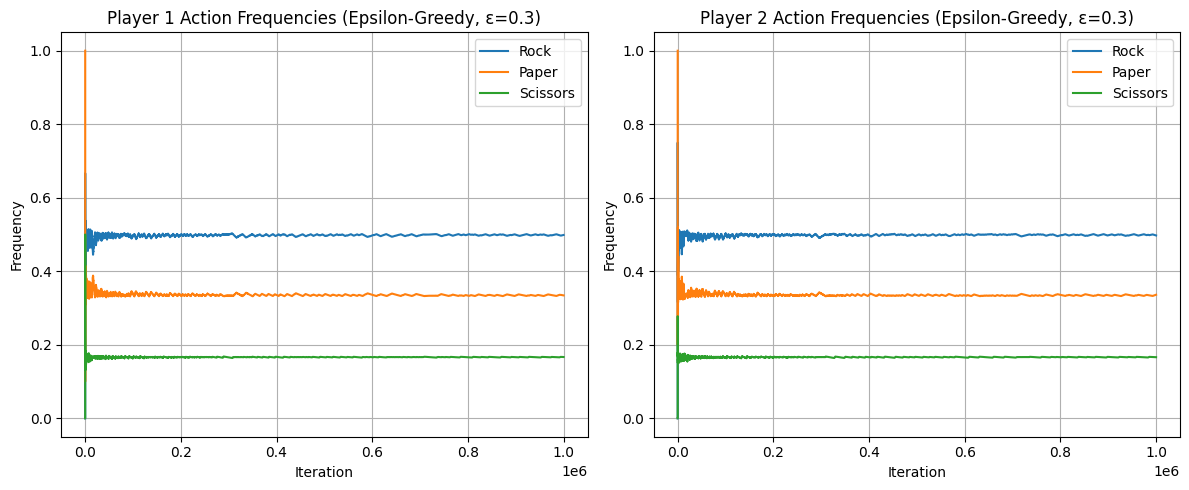

In [20]:
epss = [0.01, 0.1, 0.3]
for epsilon in epss:
    p1_freq_history, p2_freq_history = simulate_epsilon_greedy_fp(A_mod, B_mod, iterations,epsilon)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(p1_freq_history[:, 0], label='Rock')
    plt.plot(p1_freq_history[:, 1], label='Paper')
    plt.plot(p1_freq_history[:, 2], label='Scissors')
    plt.title(f'Player 1 Action Frequencies (Epsilon-Greedy, ε={epsilon})')
    plt.xlabel('Iteration')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(p2_freq_history[:, 0], label='Rock')
    plt.plot(p2_freq_history[:, 1], label='Paper')
    plt.plot(p2_freq_history[:, 2], label='Scissors')
    plt.title(f'Player 2 Action Frequencies (Epsilon-Greedy, ε={epsilon})')
    plt.xlabel('Iteration')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()




### 3.2 Analysis

**Your Task:**
1.  Run the `simulate_epsilon_greedy_fp` function on the **modified** RSP game for **1,000,000 iterations** with three different `epsilon` values: `0.01`, `0.1`, and `0.3`.
2.  Plot the results for each simulation.
3.  **Analyze your results:** How does `epsilon` affect the learning dynamics? Does the agent's strategy still converge to the NE? If not, to what does it converge? Discuss the impact of exploration in this multi-agent context.

**analyze:**


yes it does converge again. the difference is that with epsilon it may take longer  or shorter to converge. for example with eps = 0.1 is converges faster than normal. on the other hand the 0.01 or 0.3 will take a longer time to converge and also with 0.3 we see a lot of turbulance even after converging to the nash equilibruim.

---
## Problem 4: Learning from "What If" - Regret Matching (Implementation & Theory)

Regret Matching is a powerful no-regret learning algorithm. Instead of playing a best response to history, an agent's probability of choosing an action is proportional to the positive **regret** for not having chosen that action in the past. The key property of regret matching is that the **average strategy** over time converges to a Nash Equilibrium.

### 4.1 Implementation

**Your Task:** Implement the `simulate_regret_matching` function below.

**Algorithm:** Regret Matching works in two steps. First, update the cumulative regrets. Second, determine the next round's strategy.

1.  **Regret Calculation:** After playing action $a_i$ against opponent's action $a_{-i}$, the cumulative regret $R_t(s)$ for *not* having played action $s \in A_i$ is updated as follows:
    $$R_t(s) = R_{t-1}(s) + u_i(s, a_{-i}) - u_i(a_i, a_{-i})$$

2.  **Strategy Calculation:** The probability of playing action $s$ in the next round is proportional to its positive cumulative regret, $R_t^+(s) = \max(0, R_t(s))$.
    $$p_{t+1}(s) = \frac{R_t^+(s)}{\sum_{s' \in A_i} R_t^+(s')}$$
    If the sum of positive regrets is zero, play uniformly at random.

In [22]:
def simulate_regret_matching(A, B, iterations):
    """
    Simulates Regret Matching for two players.

    Returns:
        tuple: A tuple containing:
            - p1_avg_strat_hist (np.ndarray): History of Player 1's average strategy.
            - p1_inst_strat_hist (np.ndarray): History of Player 1's instantaneous strategy.
    """
    num_actions = A.shape[0]

    ### YOUR CODE HERE ###
    # Initialize regrets, strategy sums, and history lists
    # Loop for iterations
    # Calculate the current strategy based on positive regrets
    #   (If sum of positive regrets is 0, play uniformly random)
    # Store the instantaneous strategy and add to the strategy sum
    # Choose actions based on the current strategies
    # Update regrets for ALL actions based on the outcome
    # Periodically record the average and instantaneous strategies

    num_actions = A.shape[0]

    # Initialize regrets, strategy sums, and history lists for Player 1
    p1_regrets = np.zeros(num_actions)
    p1_strat_sum = np.zeros(num_actions)
    p1_inst_strat_hist = np.zeros((iterations, num_actions))
    p1_avg_strat_hist = np.zeros((iterations, num_actions))

    # Initialize regrets, strategy sums, and history lists for Player 2
    p2_regrets = np.zeros(num_actions)
    p2_strat_sum = np.zeros(num_actions)
    p2_inst_strat_hist = np.zeros((iterations, num_actions))
    p2_avg_strat_hist = np.zeros((iterations, num_actions))

    # Loop for iterations
    for t in range(iterations):
        # --- Step 1: Calculate strategies based on positive regrets ---

        # Calculate Player 1's strategy
        p1_positive_regrets = np.maximum(0, p1_regrets)
        sum_p1_regrets = np.sum(p1_positive_regrets)
        if sum_p1_regrets == 0:
            p1_inst_strat = np.ones(num_actions) / num_actions
        else:
            p1_inst_strat = p1_positive_regrets / sum_p1_regrets

        # Calculate Player 2's strategy
        p2_positive_regrets = np.maximum(0, p2_regrets)
        sum_p2_regrets = np.sum(p2_positive_regrets)
        if sum_p2_regrets == 0:
            p2_inst_strat = np.ones(num_actions) / num_actions
        else:
            p2_inst_strat = p2_positive_regrets / sum_p2_regrets

        # --- Step 2: Store instantaneous strategy and choose actions ---
        p1_inst_strat_hist[t] = p1_inst_strat
        p2_inst_strat_hist[t] = p2_inst_strat

        # Choose actions based on the current strategies
        p1_action = np.random.choice(np.arange(num_actions), p=p1_inst_strat)
        p2_action = np.random.choice(np.arange(num_actions), p=p2_inst_strat)

        # --- Step 3: Update cumulative regrets ---

        # Get payoffs for the chosen actions
        p1_payoff = A[p1_action, p2_action]
        p2_payoff = B[p1_action, p2_action]

        # Update Player 1's regrets for all actions
        regret_update_p1 = A[:, p2_action] - p1_payoff
        p1_regrets += regret_update_p1

        # Update Player 2's regrets for all actions
        regret_update_p2 = B[p1_action, :] - p2_payoff
        p2_regrets += regret_update_p2

        # --- Step 4: Update average strategies ---
        p1_strat_sum += p1_inst_strat
        p2_strat_sum += p2_inst_strat
        p1_avg_strat_hist[t] = p1_strat_sum / (t + 1)
        p2_avg_strat_hist[t] = p2_strat_sum / (t + 1)

    return p1_avg_strat_hist, p1_inst_strat_hist, p2_avg_strat_hist, p2_inst_strat_hist

In [23]:
p1_avg_hist, p1_inst_hist, p2_avg_hist, p2_inst_hist = simulate_regret_matching(A_mod, B_mod, iterations)

/tmp/ipython-input-139470189.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


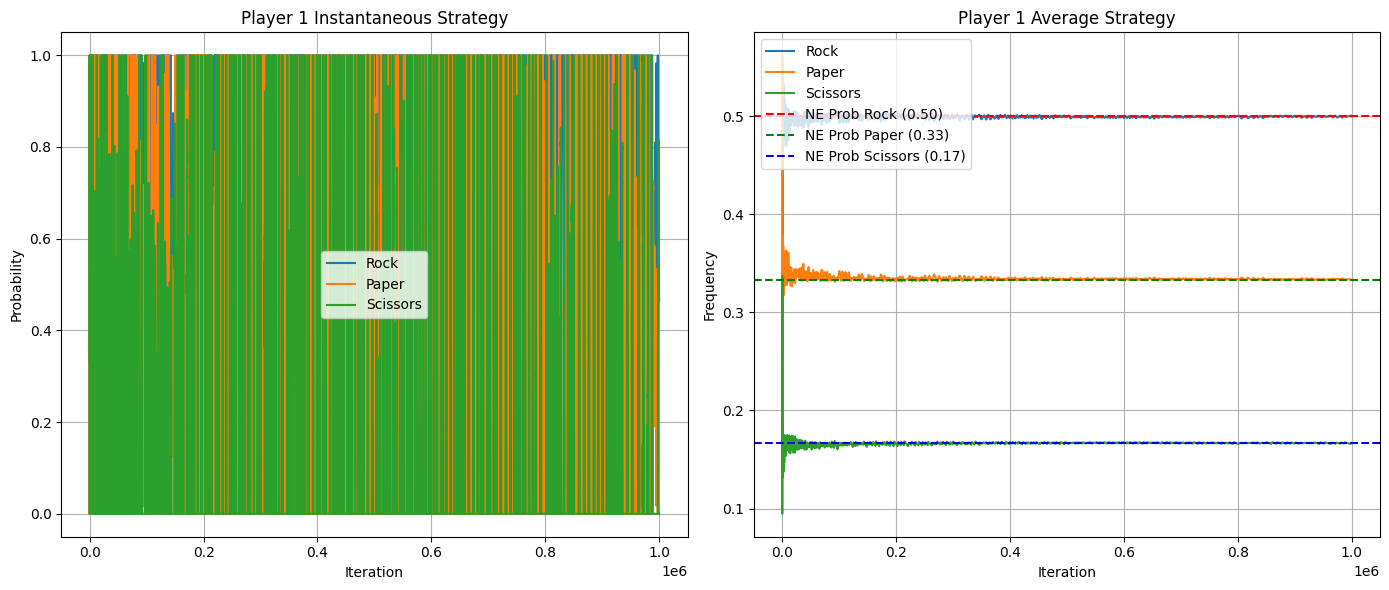

In [24]:
ne_prob = np.array([1/2, 1/3, 1/6])
# Create the plot
plt.figure(figsize=(14, 6))

# Subplot 1: Instantaneous Strategy
plt.subplot(1, 2, 1)
plt.plot(p1_inst_hist[:, 0], label='Rock')
plt.plot(p1_inst_hist[:, 1], label='Paper')
plt.plot(p1_inst_hist[:, 2], label='Scissors')
plt.title('Player 1 Instantaneous Strategy')
plt.xlabel('Iteration')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)

# Subplot 2: Average Strategy
plt.subplot(1, 2, 2)
plt.plot(p1_avg_hist[:, 0], label='Rock')
plt.plot(p1_avg_hist[:, 1], label='Paper')
plt.plot(p1_avg_hist[:, 2], label='Scissors')
plt.axhline(y=ne_prob[0], color='r', linestyle='--', label=f'NE Prob Rock ({ne_prob[0]:.2f})')
plt.axhline(y=ne_prob[1], color='g', linestyle='--', label=f'NE Prob Paper ({ne_prob[1]:.2f})')
plt.axhline(y=ne_prob[2], color='b', linestyle='--', label=f'NE Prob Scissors ({ne_prob[2]:.2f})')
plt.title('Player 1 Average Strategy')
plt.xlabel('Iteration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 4.2 Analysis

**Your Task:**
1.  Run your simulation for the **modified** RSP game for **1,000,000 iterations**.
2.  Generate a single figure with two subplots:
    * **Subplot 1:** Plot the **instantaneous strategy** of Player 1 over time.
    * **Subplot 2:** Plot the **average strategy** of Player 1 over time. Include horizontal lines for the NE.
3.  **Analyze your results:** Compare the two plots. Which one converges to the Nash Equilibrium? \
                              (Bonus): Explain why this is the expected theoretical outcome for Regret Matching algorithms.

**analyze**


 Compare the two plots. Which one converges to the Nash Equilibrium? the average one is converged to NE as expected.

 **Bonus**



the reason for this convergence lies in a core property of these algorithms: they are "no-regret" learning algorithms.

Here's a breakdown of why this happens:

1. Regret Definition: In this context, an agent's "regret" for not choosing a



2. specific action is the difference between the payoff it received from the action it did choose and the payoff it would have received if it had chosen that other action.

3. The No-Regret Property: The Regret Matching algorithm is designed to ensure that the cumulative regret for any single action becomes non-positive over a large number of iterations. In simple terms, as the game goes on, the agent's average payoff is guaranteed to be as good as the payoff it would have gotten by consistently playing any single alternative strategy.

4. Convergence to NE: In a two-player, zero-sum game like Rock-Paper-Scissors, if both players are using a no-regret algorithm, the only stable state where neither player has any regret for their actions is a Nash Equilibrium. If the average strategy were not at the NE, at least one player would have a positive cumulative regret for not playing a different action, which would cause them to adjust their strategy. This continuous adjustment process drives the average strategies of both players toward the equilibrium point, where no player has an incentive to deviate.

